# Topic Modeling

The goal of this notebook is to explore the main themes discussed in customer reviews.  
We first use **LDA**, a classical topic modeling method based on word frequencies and then compare it with **BERTopic**, a more modern embedding based approach.  

This allows us to identify the main concerns expressed by customers and to compare traditional and modern NLP methods.

### Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

#### Load dataset

In [2]:
df = pd.read_csv("../data/processed/reviews_clean.csv")

df.shape

(34433, 11)

#### Prepare text

In [3]:
texts = df["avis_clean"].dropna()

#### Remove all the french stopword (ex: de, et, pour)

In [4]:

!python -m spacy download fr_core_news_sm

import spacy

# download model (only needed once)
!python -m spacy download fr_core_news_sm

# load model
nlp = spacy.load("fr_core_news_sm")

# get French stopwords
stopwords = nlp.Defaults.stop_words

len(stopwords)

/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 27.9 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
  Using cached https://github.com/explosion/spacy-models/releases/download/fr_core_news_sm-3.8.0/fr_core_news_sm-3.8.0-py3-none-any.whl (16.3 MB)
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


507

#### Create a document-term matrix

Before applying topic modeling, we need to convert the text data into a numerical representation that a machine learning model can process.

To do this, we build a document term Matrix 

- each row represents a document (a customer review),
- each column represents a word from the vocabulary,
- each value indicates how many times a word appears in a document.


In [5]:
#vectorizer = CountVectorizer(stop_words=list(stopwords),max_df=0.95,min_df=10 )
vectorizer = CountVectorizer(stop_words=list(stopwords),ngram_range=(1, 2), max_df=0.90,min_df=10) #  we try with unigrams and bigrams to include words as "service client for ex)"

X = vectorizer.fit_transform(df["avis_clean"])

/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


### 1) Train LDA model

Once the text is represented as a document rerm matrix, we can apply Latent dirichlet allocation (LDA) to discover hidden themes in the reviews.

LDA is an unsupervised learning algorithm that identifies groups of words that frequently appear together in documents( a review here is named a "document"). These groups of words form what we call topics.

The idea behind LDA is that:

- each **review is a mixture of several topics**,
- each **topic is defined by a distribution of words**.

This allows us to better understand the main concerns and experiences expressed by customers.

In [6]:
n_topics = 5
#n_topics = 8  #we increase the number of topics to obtain more specific themes. With too few topics, different subjects may be mixed together.

lda = LatentDirichletAllocation(n_components=n_topics,random_state=42)

lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

#### Get vocabulary

In [7]:
feature_names = vectorizer.get_feature_names_out()

#### Function to display topics

In [8]:
def print_topics(model, feature_names, n_words=10):
    
    for topic_idx, topic in enumerate(model.components_):
        
        words = [feature_names[i] for i in topic.argsort()[:-n_words - 1:-1]]
        
        print(f"Topic {topic_idx+1}:")
        print(" | ".join(words))
        print()

#### Show topics


LDA does not assign one word to only one topic.  
Instead, each topic is defined as a distribution of words and each review is modeled as a mixture of topics.
As a result, some frequent words may appear in several topics, especially when they are common across many customer reviews. The model provides groups of co occurring words and we then infer the underlying theme.

In [9]:
print_topics(lda, feature_names)


Topic 1:
contrat | qu | assurance | client | service | demande | faire | mail | été | bien

Topic 2:
prix | assurance | service | satisfait | recommande | satisfait service | satisfaite | bien | client | direct

Topic 3:
mois | mutuelle | qu | remboursement | dossier | assurance | rien | euros | faire | aucune

Topic 4:
rapide | bien | prix | site | simple | devis | facile | souscription | été | voir

Topic 5:
assurance | sinistre | ans | qu | véhicule | voiture | été | accident | expert | non



#### Interpretation of topics

After applying LDA, we manually interpret each topic based on its most frequent words. By analyzing these words, we can identify the main themes discussed by users.


**Topic 1 : Customer service and communication issues**  
This topic likely represents customer interactions, including requests, communication problems and service responsiveness.

**Topic 2 : Satisfaction and positive experience**  
This reflects positive customer experiences and general satisfaction with the service.

**Topic 3 : Reimbursement and administrative delays**  
This topic indicates issues related to reimbursement processes, delays and lack of response from the insurer.

**Topic 4 – Subscription and pricing experience**  
This topic likely represents the subscription process, pricing and ease of use of the platform.

**Topic 5 – Claims and accidents (vehicle insurance)**  
This topic point to insurance claims particularly related to car accidents and claim handling.

#### Assign a topic to each review

In [10]:
topic_results = lda.transform(X)

df["topic"] = topic_results.argmax(axis=1)

df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,source_file,avis_clean,topic
0,NaN,estelle-51227,j'ai quitté mon ancien contrat d'assurance che...,Néoliane Santé,sante,test,2017-01-12,2017-01-01,I left my former insurance contract at General...,avis_33_traduit.xlsx,j ai quitté mon ancien contrat d assurance che...,2
1,NaN,leadum-51107,j'ai souscrit à cette mutuelle l'année dernier...,Néoliane Santé,sante,test,2017-01-09,2017-01-01,I subscribed to this mutual a year last year a...,avis_33_traduit.xlsx,j ai souscrit à cette mutuelle l année dernier...,2
2,NaN,enora-49520,"Impossible d'avoir le bon service , ils raccro...",Néoliane Santé,sante,test,2016-11-24,2016-11-01,"Impossible to have the right service, they han...",avis_33_traduit.xlsx,impossible d avoir le bon service ils raccroch...,0
3,NaN,bea-139295,Génération est une mutuelle très chère pour un...,Génération,sante,test,2021-11-09,2021-11-01,Generation is a very expensive mutual for a re...,avis_33_traduit.xlsx,génération est une mutuelle très chère pour un...,0
4,NaN,anna-139192,je viens d apprendre que je suis radié... j ap...,Génération,sante,test,2021-11-08,2021-11-01,I just learned that I am struck off ... I call...,avis_33_traduit.xlsx,je viens d apprendre que je suis radié j appel...,2


#### Distribution of topics

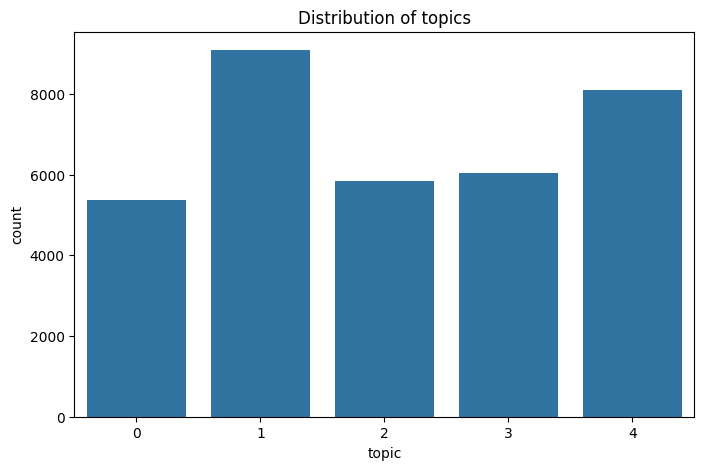

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(x="topic", data=df)

plt.title("Distribution of topics")

plt.show()

The distribution of the different topic is pretty much alike.

#### Topics by rating

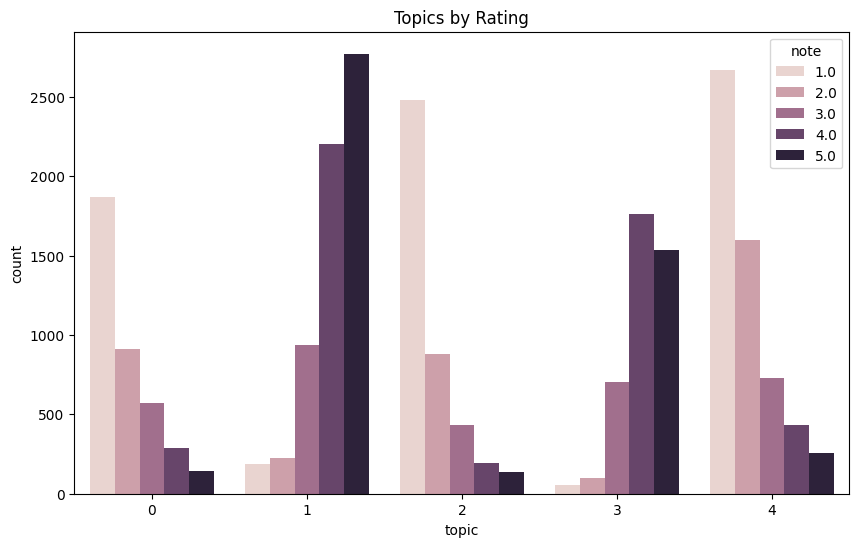

In [12]:
df_supervised = df.dropna(subset=["note"])

plt.figure(figsize=(10,6))

sns.countplot(x="topic", hue="note", data=df_supervised)

plt.title("Topics by Rating")

plt.show()

The rating distribution within each topic helps us understand whether a given theme is mainly associated with positive or negative customer experiences. It shows that the topic are corrolated to the topic.

### 2) BERTopic

Unlike LDA, which relies on word frequency counts, BERTopic uses contextual embeddings to represent documents.  

This allows the model to group reviews based on their semantic meaning, rather than only the words they contain.  

#### Install required librairies

In [13]:
%pip install bertopic sentence-transformers umap-learn hdbscan spacy
!python -m spacy download fr_core_news_sm

Note: you may need to restart the kernel to use updated packages.
/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
  Using cached https://github.com/explosion/spacy-models/releases/download/fr_core_news_sm-3.8.0/fr_core_news_sm-3.8.0-py3-none-any.whl (16.3 MB)
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


#### Import librairies

In [14]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

import spacy
import matplotlib.pyplot as plt
import seaborn as sns

#### Prepare text data

Although BERTopic relies on contextual embeddings, the extraction of topic keywords still depends on a vectorization step.

For this reason, we remove french stopwords and some very generic words from the dataset in order to obtain more interpretable topics.

However, we keep negation words such as **"pas"**, **"ne"**, and **"jamais"** because they are important for customer sentiment.

- Stopwords

In [ ]:

nlp = spacy.load("fr_core_news_sm") #french model for stopwords

custom_stopwords = set(nlp.Defaults.stop_words)

# we keep negation words because they are important for sentiment.
custom_stopwords = custom_stopwords - {"pas", "ne", "jamais"}

# we manually add frequent words that are too generic in this insurance dataset and do not help distinguish meaningful topics.
custom_stopwords.update(["de", "la", "le", "les", "des", "du","un", "une", "et", "en", "je", "vous",
    "ils", "elles", "nous", "qui", "que","pour", "avec", "être", "été", "assurance", "mutuelle"])

- Final text 

In [ ]:
# we create a text version specifically designed for topic modeling. this version removes stopwords while keeping informative words.
def clean_for_topics(text):
    words = str(text).split()
    words = [w for w in words if w not in custom_stopwords and len(w) > 2]
    return " ".join(words)

df["avis_topic"] = df["avis_clean"].apply(clean_for_topics)

# Bertopic requires a list of text documents.
texts = df["avis_topic"].dropna().tolist()
#texts = df["avis_clean"].dropna().tolist() # we use the original cleaned text (not aggressively filtered) because embeddings need full semantic context(not the case for topic).

len(texts)

34433

#### Load embedding model

In [17]:
# we use a multilingual embedding model because the reviews are in french.
# this model transforms each review into a semantic vector.
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

#### Define BERTopic vectorizer

Even though BERTopic uses embeddings, topic keywords are still extracted through a vectorizer.

We therefore provide a custom `CountVectorizer` with our stopwords and include both unigrams and bigrams to obtain more meaningful topic labels.

In [18]:
# we use a custom vectorizer so that BERTopic extracts cleaner and more informative keywords.
#vectorizer_model = CountVectorizer(stop_words=list(custom_stopwords),ngram_range=(1, 2),min_df=10)  #we remove stopwords and include bigrams to get more meaningful keywords.
vectorizer_model = CountVectorizer(ngram_range=(1, 2),min_df=10)

#### Train BERTopic model

In [19]:
# BERTopic groups semantically similar reviews and extracts representative keywords.
topic_model = BERTopic(embedding_model=embedding_model,vectorizer_model=vectorizer_model,
    language="multilingual",calculate_probabilities=True,verbose=True)

topics, probs = topic_model.fit_transform(texts)

2026-03-21 20:02:34,129 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1077 [00:00<?, ?it/s]

2026-03-21 20:04:00,037 - BERTopic - Embedding - Completed ✓
2026-03-21 20:04:00,046 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-21 20:04:25,441 - BERTopic - Dimensionality - Completed ✓
2026-03-21 20:04:25,446 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-21 20:05:05,231 - BERTopic - Cluster - Completed ✓
2026-03-21 20:05:05,257 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-21 20:05:06,414 - BERTopic - Representation - Completed ✓


 #### Overview of discovered topics

In [20]:
# this table shows all discovered topics, their sizes and representative keywords.
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,17384,-1_pas_mois_contrat_sinistre,"[pas, mois, contrat, sinistre, véhicule, faire...",[retard côté presse adhérents cotisations susp...
1,0,2284,0_téléphonique_téléphone_accueil téléphonique_...,"[téléphonique, téléphone, accueil téléphonique...",[bon relationnel accueil téléphonique parfait ...
2,1,1501,1_téléphone_mails_mail_impossible,"[téléphone, mails, mail, impossible, réponse, ...",[essaie contacter direct téléphone mail whatsa...
3,2,1149,2_site_internet_site internet_facile,"[site, internet, site internet, facile, utilis...",[satisfait service prix conviennent simple pra...
4,3,922,3_sinistre_mauvaise_fuir_client,"[sinistre, mauvaise, fuir, client, pas, éviter...",[déclaré sinistre maif dégâts dégradations loc...
5,4,636,4_moto_scooter_amv_april moto,"[moto, scooter, amv, april moto, april, motard...",[amv propose excellents services motards jours...
6,5,605,5_euros_eurofil_euro_euros mois,"[euros, eurofil, euro, euros mois, mois, cotis...",[113 euros mois cotisation rembourse peine 160...
7,6,548,6_assurer_véhicules_assurer véhicule_satisfait,"[assurer, véhicules, assurer véhicule, satisfa...",[satisfait prix convient services demander ass...
8,7,526,7_eaux_dégât_dégât eaux_eau,"[eaux, dégât, dégât eaux, eau, dégâts, fuite, ...",[prélever mensualités pas problème ensuite nul...
9,8,516,8_contrat_satisfait_contrats_satisfait contrat,"[contrat, satisfait, contrats, satisfait contr...",[parfait rapidité devis contrat proposé accuei...


#### Display topic keywords

In [21]:
# we display the main keywords for the first topics (excluding outliers).
for topic_id in topic_model.get_topic_info()["Topic"].head(10):
    if topic_id != -1:
        print(f"Topic {topic_id}:")
        print(topic_model.get_topic(topic_id))
        print()

Topic 0:
[('téléphonique', np.float64(0.03439340188892793)), ('téléphone', np.float64(0.026968870886419735)), ('accueil téléphonique', np.float64(0.022224635227058347)), ('accueil', np.float64(0.020019817689853336)), ('agréable', np.float64(0.014848781400912817)), ('satisfait', np.float64(0.011794487646380476)), ('bon', np.float64(0.011243015649021765)), ('contact', np.float64(0.011038876068686074)), ('rapide', np.float64(0.010986992939846476)), ('satisfaite', np.float64(0.01093830269350252))]

Topic 1:
[('téléphone', np.float64(0.013535213033001555)), ('mails', np.float64(0.012561071982441673)), ('mail', np.float64(0.012492167547802214)), ('impossible', np.float64(0.011409551359460625)), ('réponse', np.float64(0.009591112318453004)), ('contrat', np.float64(0.008852971817504945)), ('pas', np.float64(0.007591011646974503)), ('aucune', np.float64(0.0074593972211126555)), ('aucune réponse', np.float64(0.006935532112017282)), ('client', np.float64(0.006925315950530223))]

Topic 2:
[('site'

#### Interpreting BERTOpic results

**Topic 0 : Telephone customer service**  
This topic focuses on telephone interactions with customer support.  

**Topic 1 : Advisor quality and customer interaction**  
This topic highlights the role of advisors listening and professionalism.  

**Topic 2 : Insurance products (auto and home) and satisfaction**  
This topic relates to insured products such as vehicles and housing.  

**Topic 3 : Website and digital experience**  
This topic captures online interactions, including ease of use and website navigation. It reflects digital customer experience and is mostly associated with convenience and usability.

**Topic 4 : Overall service quality and value for money**  
This topic focuses on general satisfaction with service and pricing.  

**Topic 5 : Negative customer experience and complaints**  
This is a clearly negative topic.It reflects dissatisfaction, especially with customer service and claim handling.

**Topic 6 : Motorcycle insurance segment**  
This topic is specific to motorcycle related insurance. It represents a distinct customer segment with its own vocabulary.

**Topic 7 : Price increases and premium changes**  
This topic captures complaints about increasing prices.  
It likely reflects customer frustration over rising insurance costs.

**Topic 8 : Costs, payments, and fees**  
This topic is related to financial aspects such as payments, fees, and monthly costs. It reflects discussions around pricing and affordability.

#### Assign topics to reviews

In [22]:
df_bertopic = df.iloc[:len(texts)].copy()
df_bertopic["bertopic_topic"] = topics

#### Topic distribution

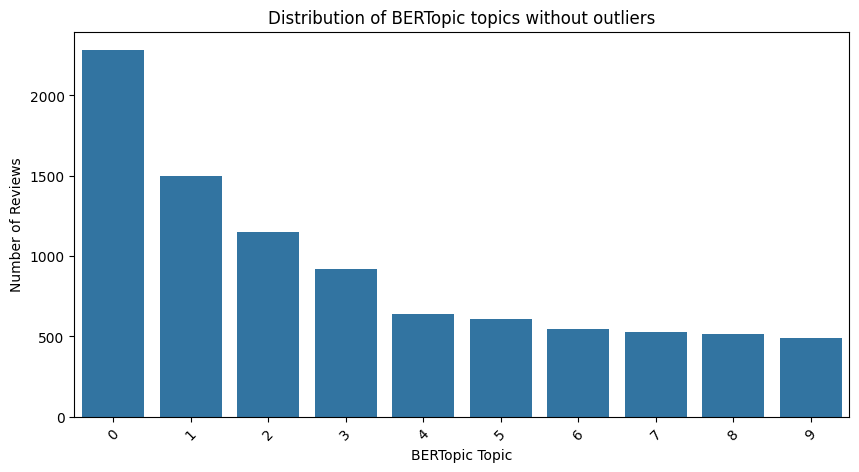

In [23]:
df_bertopic_filtered = df_bertopic[df_bertopic["bertopic_topic"] != -1].copy() # we filter out outliers (-1)to get a clearer view of the main topics.
plt.figure(figsize=(10, 5))
sns.countplot(x="bertopic_topic",data=df_bertopic_filtered,order=df_bertopic_filtered["bertopic_topic"].value_counts().index[:10])

plt.title("Distribution of BERTopic topics without outliers")
plt.xlabel("BERTopic Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

#### Rating distribution by topic

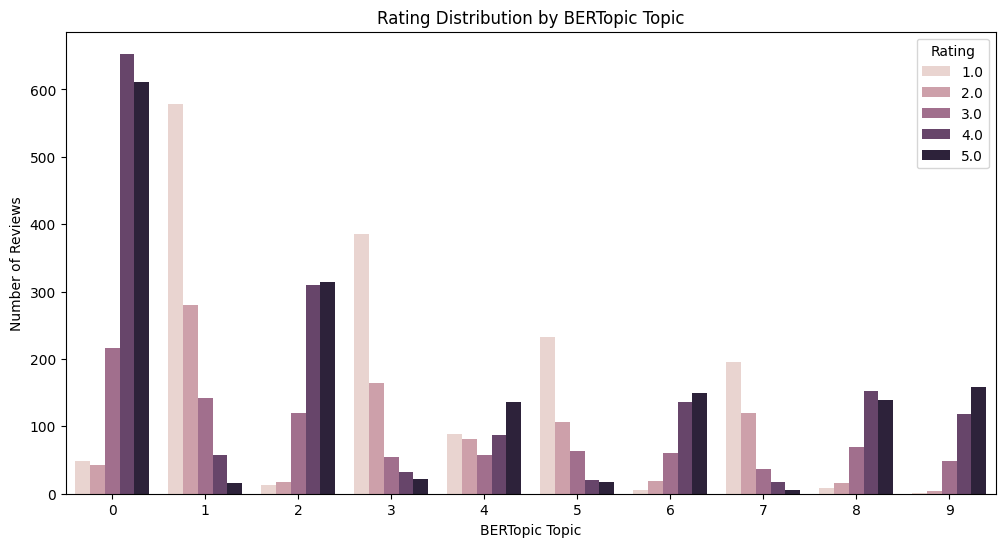

In [24]:
# we keep only reviews that have a rating in order to compare topics with customer satisfaction.
df_bertopic_supervised = df_bertopic_filtered.dropna(subset=["note"]).copy()

plt.figure(figsize=(12, 6))
sns.countplot(data=df_bertopic_supervised,x="bertopic_topic",order=df_bertopic_filtered["bertopic_topic"].value_counts().index[:10],hue="note")

plt.title("Rating Distribution by BERTopic Topic")
plt.xlabel("BERTopic Topic")
plt.ylabel("Number of Reviews")
plt.legend(title="Rating")
plt.show()

The rating distributing by topic is corrolated to the interpretaion of Bertopics that we did some cells above. 

#### Average rating by topic

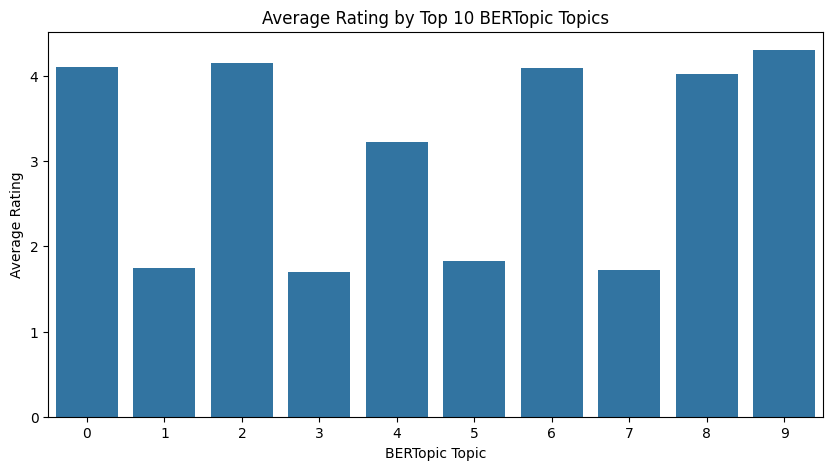

In [25]:
# compute average rating per topic
topic_rating = (df_bertopic_supervised.groupby("bertopic_topic")["note"].mean())

# keep only 10 most frequent topics
top_topics = df_bertopic_supervised["bertopic_topic"].value_counts().head(10).index
topic_rating_top = topic_rating.loc[top_topics].sort_values()

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=topic_rating_top.index, y=topic_rating_top.values)
plt.title("Average Rating by Top 10 BERTopic Topics")
plt.xlabel("BERTopic Topic")
plt.ylabel("Average Rating")

plt.show()

#### Topic visualization

In [26]:
# interactive visualization of topics
topic_model.visualize_barchart(top_n_topics=10)

In [27]:
topic_model.visualize_topics()

#### Conclusion


Both LDA and Bertopic helped identify the main themes discussed in customer reviews.  
LDA provided a first frequency based overview of the corpus while Bertopic produced more semantically coherent and interpretable topics.

The analysis also showed that some topics are clearly associated with positive customer experiences whereas others are linked to complaints, price increases or claims handling.

Overall, topic modeling provides a strong thematic understanding of the dataset and complements the supervised learning tasks developed later in the project.